In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from tqdm import tqdm

n = 1
# mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
mechanisms = ['MNAR_l', 'MNAR_m']

IMP_MODELS = [
    'none',
    'mean',
    'reg_opt_00001',
    'tree_gp_10000',
    'tree_ad_gp_10000',
    'mlp_opt_0001'
]

imp_label = {
    'none': 'None',
    'mean': 'Mean',
    'reg_opt_00001': 'LR',
    'tree_gp_10000': 'HT',
    'tree_ad_gp_10000': 'HAT',
    'mlp_opt_0001': 'MLP',
}

imp_markers = {
    'none': 'X',
    'mean': 'o',
    'reg_opt_00001': 'o',
    'tree_gp_10000': 'o',
    'tree_ad_gp_10000': 'o',
    'mlp_opt_0001': 'o',
}

imp_colors = {
    'none': (0.0, 0.0, 0.0),  # preto
    'mean': (0.5, 0.5, 0.5),  # cinza
    'reg_opt_00001': (1.00, 0.70, 0.30),   # laranja claro
    'tree_gp_10000': (0.95, 0.50, 0.15),   # laranja médio
    'tree_ad_gp_10000': (0.80, 0.30, 0.05),   # laranja escuro
    'mlp_opt_0001': (1.00, 0.00, 1.00),   # magenta
}

mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_")
        mec_label = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_label = mec
    mec_labels[mec] = mec_label



mr_values = ["05", "10", "15", "20", "25"]

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = {
    'MCAR':   (0.25, 0.85, 0.35),   # verde vibrante
    'MAR_l':  (1.00, 0.70, 0.30),   # laranja claro
    'MAR_m':  (0.95, 0.50, 0.15),   # laranja médio
    'MAR_h':  (0.80, 0.30, 0.05),   # laranja escuro
    'MNAR_l': (0.45, 0.70, 1.00),   # azul claro
    'MNAR_m': (0.25, 0.50, 0.95),   # azul médio
    'MNAR_h': (0.10, 0.35, 0.85),   # azul escuro
}
EXCLUDED_PATIENTS = ['AJ7TSV9','AS2MVDL']
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_m': 'D', 'MAR_h': '^', 'MNAR_l': 'X', 'MNAR_m': 'P', 'MNAR_h': 'H'}

order = ['ATHKM6V', 'AUY8KYW', 'AURCTAK', 'AX6281V', 'AOYM4KG', 'A4G0044', 'A7EM0B6', 'AQC0L71', 'AZIK4ZA', 'AHYIJDV', 'AAXAA7Z', 'A1ZJ41O', 'AFPB8J2', 'ASFODQR', 'A0VFT1N', 'AJWW3IY', 'AV2GF3B', 'AKXN5ZZ', 'A1K5DRI', 'A4E0D03', 'APGIB2T', 'A3OU183', 'AYWIEKR', 'A0NVTRV', 'AIFDJZB', 'A36HR6Y', 'AA2KP1S', 'AJMQUVV', 'AMV7EQF', 'AYEFCWQ']



In [26]:
class ConfusionMatrix:

    metrics_table_mec_imp = {mec: {imp: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1_Score']) 
            for imp in IMP_MODELS} for mec in mechanisms}
    

    def __init__(self, metric):
        self.metric = metric
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") 
                         if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient)) and patient not in EXCLUDED_PATIENTS]
        # self._plot_og_anomalies()
        self._metrics_df()

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN 
    
    # Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
    def _plot_og_anomalies(self):
        tuples_count = {}
        for patient in self.patients:
            if patient in EXCLUDED_PATIENTS:
                continue
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
                tuples_count[patient] = len(df_full)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                tuples_count[patient] = 0
                self.patients.remove(patient)

        # Plotar os resultados
        plt.figure(figsize=(15, 6))
        plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
        plt.xlabel('Pacientes')
        plt.ylabel('Quantidade de Tuplas')
        plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
        plt.xticks(rotation=45)
        # Adicionar os valores absolutos acima de cada barra
        for i, (patient, count) in enumerate(tuples_count.items()):
            plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)
        plt.show()

    def _metrics_df(self):

        print(f"Calculando métricas para {self.metric}...")

        for mec in mechanisms:

            results = {}
            absolute = {}

            for imp in IMP_MODELS:

            # Adicionar barra de progresso
                for patient in tqdm(self.patients, desc=f"Processando pacientes para {mec} - {imp}"):
                
                # Carregar df_full
                    try:
                        df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
                    except (FileNotFoundError, pd.errors.EmptyDataError):
                        print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                        continue
                    
                    dfs_imp = {}
                    if imp == 'none':
                        for mr_value in mr_values:
                            dfs_imp[mr_value] = {}
                            for i in range(1, n + 1):
                                file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'
                                if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                                    dfs_imp[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                                else:
                                    if not os.path.exists(file_path):
                                        continue
                                    elif os.path.getsize(file_path) == 0:
                                        dfs_imp[mr_value][i] = pd.DataFrame(columns=[1, 2])  
                    else:
                        for mr_value in mr_values:
                            dfs_imp[mr_value] = {}
                            for i in range(1, n + 1):
                                file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{imp}/{patient}_anomalies_{mec}_{i}_{mr_value}_{imp}.csv'
                                if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                                    dfs_imp[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                                else:
                                    if not os.path.exists(file_path):
                                        continue
                                    elif os.path.getsize(file_path) == 0:
                                        dfs_imp[mr_value][i] = pd.DataFrame(columns=[1, 2])  

                    precision_list = {mr: [] for mr in mr_values}
                    recall_list = {mr: [] for mr in mr_values}

                    for mr, dfs in dfs_imp.items():
                        for key, df_imp in dfs.items():
                            y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_full[1], df_full[1])]
                            y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_imp[1], df_imp[1])]

                            TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)

                            if mr not in absolute:
                                absolute[mr] = {'TP': [], 'FP': [], 'FN': []}
                            absolute[mr]['TP'].append(TP)
                            absolute[mr]['FP'].append(FP)
                            absolute[mr]['FN'].append(FN)

                            precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                            recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                            precision_list[mr].append(precision)
                            recall_list[mr].append(recall)

                mean_precision_by_mr = {mr: [] for mr in mr_values}
                mean_recall_by_mr = {mr: [] for mr in mr_values}

                for mr in mr_values:
                    precision_sum = sum(precision_list[mr])
                    recall_sum = sum(recall_list[mr])
                    count = len(precision_list[mr])

                    mean_precision_by_mr[mr] = precision_sum / count if count > 0 else 0
                    mean_recall_by_mr[mr] = recall_sum / count if count > 0 else 0

                for mr in mr_values:
                    if mr not in results:
                        results[mr] = {'precision': [], 'recall': []}
                    results[mr]['precision'].append(mean_precision_by_mr[mr])
                    results[mr]['recall'].append(mean_recall_by_mr[mr])

                # Inicializar os valores totais de TP, FP, FN
                # Inicializar os valores totais de TP, FP, FN por MR
                total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute.items()}
                total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute.items()}
                total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute.items()}

                # Inicializar listas para armazenar as métricas
                accuracy_list = []
                precision_list = []
                f1_list = []
                recall_list = []

                # Calcular métricas para cada MR
                for mr in mr_values:
                    tp = total_tp_by_mr[mr]
                    fp = total_fp_by_mr[mr]
                    fn = total_fn_by_mr[mr]
                    total_instances = tp + fp + fn

                    # Calcular acurácia, precisão, revocação e F1
                    accuracy = tp / total_instances if total_instances > 0 else 0
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                    # Adicionar métricas às listas
                    accuracy_list.append(accuracy * 100)
                    precision_list.append(precision * 100)
                    recall_list.append(recall * 100)
                    f1_list.append(f1 * 100)

                # Criar um DataFrame com as métricas
                metrics_table = pd.DataFrame({
                    'MR': mr_values,
                    'Accuracy': accuracy_list,
                    'Precision': precision_list,
                    'Recall': recall_list,
                    'F1_Score': f1_list
                })

                # Adicionar a tabela de métricas ao DataFrame geral
                self.metrics_table_mec_imp[mec][imp] = metrics_table
                print(metrics_table)

In [27]:
results_rhr = ConfusionMatrix("RHR")

Calculando métricas para RHR...


Processando pacientes para MNAR_l - none:   0%|          | 0/30 [00:00<?, ?it/s]

Processando pacientes para MNAR_l - none: 100%|██████████| 30/30 [01:20<00:00,  2.70s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  71.459538  76.845377  91.068140  83.354404
1  10  59.346581  68.855021  81.123389  74.487423
2  15  49.104775  63.698925  68.186004  65.866133
3  20  43.791722  61.423221  60.405157  60.909935
4  25  38.842689  61.089918  51.611418  55.952084


Processando pacientes para MNAR_l - mean: 100%|██████████| 30/30 [01:35<00:00,  3.17s/it]


...

   MR   Accuracy  Precision     Recall   F1_Score
0  05  76.950690  81.103146  93.761510  86.974162
1  10  70.610481  76.432749  90.262431  82.773908
2  15  64.331044  72.442487  85.174954  78.294451
3  20  60.521415  69.579603  82.297422  75.406032
4  25  55.254908  66.107383  77.094843  71.179596


Processando pacientes para MNAR_m - tree_ad_gp_10000: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  78.645473  82.563482  94.309392  88.046422
1  10  72.253829  77.657573  91.215470  83.892276
2  15  66.390856  73.572150  87.182320  79.801087
3  20  62.442977  70.557009  84.447514  76.879873
4  25  57.546982  67.361057  79.797422  73.053741


Processando pacientes para MNAR_m - mlp_opt_0001: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it]

   MR   Accuracy  Precision     Recall   F1_Score
0  05  79.717255  83.394111  94.759055  88.714080
1  10  73.195183  78.256323  91.881522  84.523347
2  15  67.571059  74.222681  88.290362  80.647648
3  20  63.712623  71.309957  85.673726  77.834710
4  25  59.155400  68.272009  81.583794  74.336654


In [30]:
# Consolidate results_rhr into a single CSV with mechanism and imputation method columns

dfs_consolidated = []

for mec in results_rhr.metrics_table_mec_imp:
    for imp in results_rhr.metrics_table_mec_imp[mec]:
        df = results_rhr.metrics_table_mec_imp[mec][imp].copy()
        df['Mechanism'] = mec
        df['Imputation_Method'] = imp
        dfs_consolidated.append(df)

df_final = pd.concat(dfs_consolidated, ignore_index=True)

# Reorder columns to put Mechanism and Imputation_Method first
cols = ['Mechanism', 'Imputation_Method', 'MR', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
df_final = df_final[cols]
# Map imputation method names using imp_label
df_final['Imputation_Method'] = df_final['Imputation_Method'].map(imp_label)

# Save to CSV
df_final.to_csv('results_rhr.csv', index=False)

In [23]:
def metric_lineplot(matrix):

    for mec_name, mec_tables in matrix.metrics_table_mec_imp.items():

        dfs = []
        for imp, df in mec_tables.items():
            df = df.copy()
            df["imp"] = imp
            dfs.append(df)

        df_all = pd.concat(dfs, ignore_index=True)

        n_metrics = len(metric_names)
        fig, axes = plt.subplots(
            1, n_metrics,
            figsize=(12, 4),
            sharey=True
        )

        # garante que axes seja iterável mesmo com 1 métrica
        if n_metrics == 1:
            axes = [axes]

        for ax, metric in zip(axes, metric_names):
            sns.lineplot(
                data=df_all,
                x="MR",
                y=metric,
                hue="imp",
                style="imp",              
                markers=imp_markers,      
                palette=imp_colors,
                dashes=False,            
                ax=ax,
            )

            ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)
            ax.set_title(metric, fontsize=10)
            ax.set_xlabel("Missing Rate (%)", fontsize=9)
            ax.set_ylim(30, 100)
            ax.set_ylabel(f"{metric} (%)", fontsize=9)
            ax.tick_params(axis="both", labelsize=8)

            # remove legend duplicada
            ax.legend_.remove()

        # legenda única para a figura inteira
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, imp_label.values(),
            title="Imputation Method",
            fontsize=8,
            title_fontsize=9,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.95),  # <-- sobe a legenda
            ncol=len(imp_label),
            frameon=False,
        )

        # título da figura um pouco abaixo
        fig.suptitle(
            mec_labels.get(mec_name, mec_name),
            fontsize=11,
            y=0.8  # <-- desce o título
        )

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()

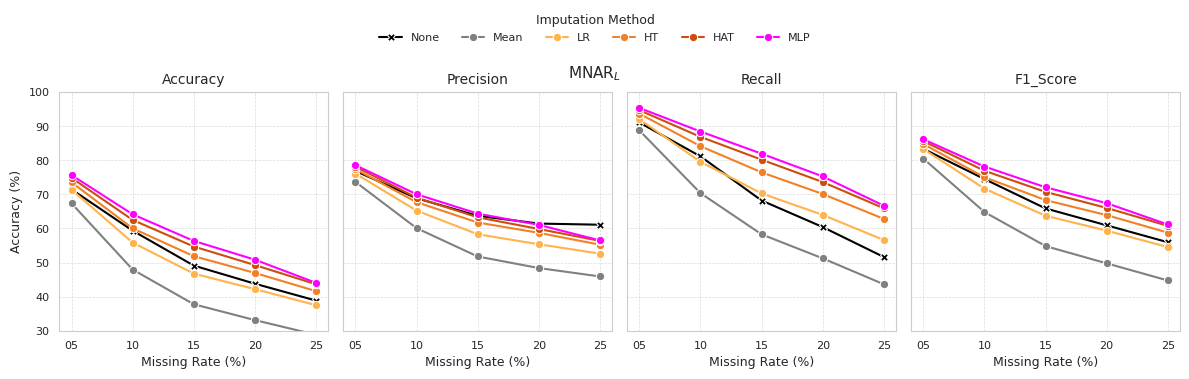

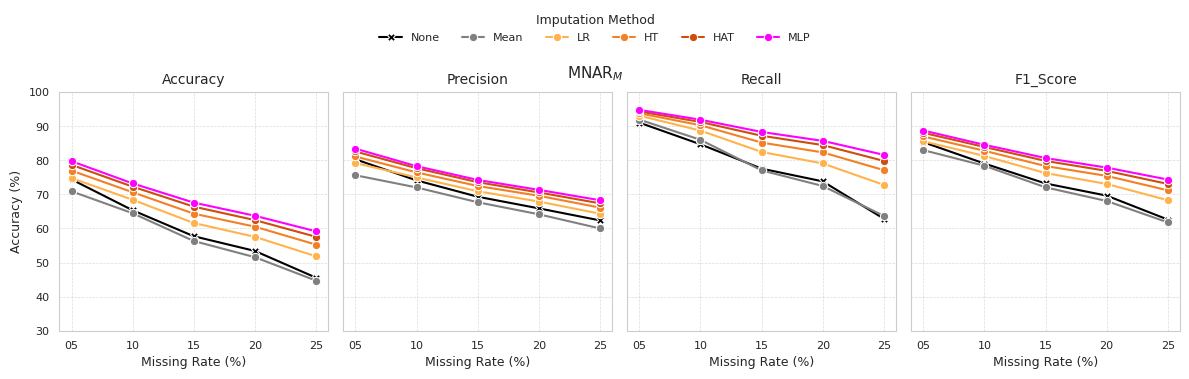

In [28]:
metric_lineplot(results_rhr)
